In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

%matplotlib inline

In [9]:
# ── Whether to rotate window after applying theta cut  ----------──────────────
rotate_window = False   # set False to use the unrotated covariance

# ── Paths ─────────────────────────────────────────────────────────────────────
db         = 'data/'
d_analytic = db + 'analytics/'

# ── Load k and r grids ────────────────────────────────────────────────────────
pkd  = np.loadtxt(db + 'pkxi_dat/Pk_LRG2_ell02.txt')
xid  = np.loadtxt(db + 'pkxi_dat/Xipost_LRG2_ell02.txt')
konh = pkd[:, 0]   # k-bin centres [h/Mpc]
r    = xid[:, 0]   # r-bin centres [Mpc/h]

# ── Dimensions & block boundaries ─────────────────────────────────────────────
poles          = [0, 2]   # Pk and Xi multipoles used in the files
nk             = pkd.shape[0]   # 80
nr             = xid.shape[0]   # 50
Np0            = nk              # k-bins per Pk pole
n_poles_in_file = 2
Pk_end         = n_poles_in_file * nk   # 160: end of Pk block in joint cov

# ── Load simulated covariance ─────────────────────────────────────────────────
if rotate_window:
    cov_fn = 'pkxi_cov/PkXi_joint_LRG2_ell02_cov_rotated_hack.txt'
else:
    cov_fn = 'pkxi_cov/PkXi_joint_LRG2_ell02_cov.txt'
cov = np.loadtxt(db + cov_fn)

# ── Load analytic joint covariance and extract Pk–Xi cross block ──────────────
# Layout of the (260, 260) file: [Pk0[80], Pk2[80], Xi0[50], Xi2[50]]
cov_analytic_full  = np.loadtxt(
    d_analytic + 'PkXi_joint_LRG2_ell02_cov_analyticPkXi_V2p9_0p6SN.txt')
cov_analytic_cross = cov_analytic_full[:Pk_end, Pk_end:]   # (160, 100)

# ── Apply window rotation if requested ───────────────────────────────────────
if rotate_window:
    # Load pre-saved rotated cross-block (generated by the cell below)
    cov_analytic_cross = np.loadtxt(
        d_analytic + 'PkXi_joint_LRG2_ell02_cov_analytic_cross_rotated.txt')

print(f'rotate_window = {rotate_window}')
print(f'cov shape: {cov.shape},  cov_analytic_cross shape: {cov_analytic_cross.shape}')

rotate_window = False
cov shape: (260, 260),  cov_analytic_cross shape: (160, 100)


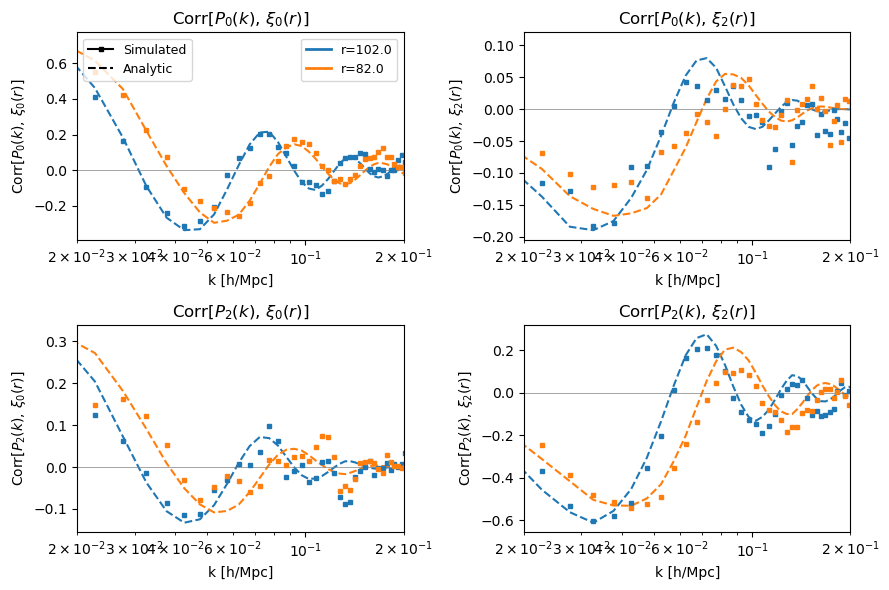

In [10]:
# ── 1-D slices of the Pk–Xi correlation at fixed r-bins ───────────────────────
rbins    = np.array([25, 20])
cov_diag = np.diag(cov)

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
pole_combinations = [(0, 0), (0, 2), (2, 0), (2, 2)]

for idx, (Pkpole, Xipole) in enumerate(pole_combinations):
    row = idx // 2
    col = idx % 2
    ax  = axes[row, col]

    Pkidx = poles.index(Pkpole)
    xiidx = poles.index(Xipole)

    var_Pk = cov_diag[Pkidx * Np0 : (Pkidx + 1) * Np0]   # (nk,)

    for i, rbin in enumerate(rbins):
        xi_global_idx = rbin + Np0 * n_poles_in_file + nr * xiidx
        var_Xi  = cov_diag[xi_global_idx]
        denom   = np.sqrt(var_Pk * var_Xi)

        cvec   = cov[Pkidx * Np0 : (Pkidx + 1) * Np0, xi_global_idx]
        theory = cov_analytic_cross[Pkidx * nk : (Pkidx + 1) * nk,
                                    xiidx * nr + rbin]

        ax.errorbar(konh, cvec   / denom, fmt='s', color=f'C{i}', markersize=3)
        ax.plot(    konh, theory / denom, color=f'C{i}', ls='--')

    ax.set_ylabel(rf'$\mathrm{{Corr}}[P_{{{Pkpole}}}(k),\,\xi_{{{Xipole}}}(r)]$')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_xscale('log')
    ax.set_xlim([0.02, 0.2])
    ax.axhline(0, color='gray', ls='-', lw=0.5)
    ax.set_title(rf'Corr[$P_{{{Pkpole}}}(k)$, $\xi_{{{Xipole}}}(r)$]')

    if idx == 0:
        legend_elements = [
            Line2D([0], [0], color=f'C{i}', lw=2, label=f'r={xid[rb, 0]:.1f}')
            for i, rb in enumerate(rbins)
        ]
        line_legend = [
            Line2D([0], [0], color='k', marker='s', linestyle='-', markersize=3, label='Simulated'),
            Line2D([0], [0], color='k', linestyle='--', label='Analytic'),
        ]
        leg1 = ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
        leg2 = ax.legend(handles=line_legend,     loc='upper left',  fontsize=9)
        ax.add_artist(leg1)

fig.tight_layout()
plt.show()

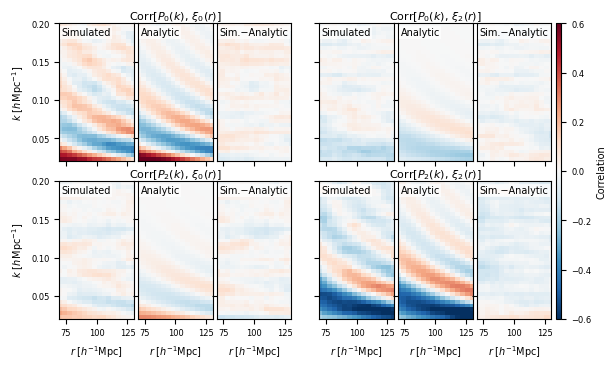

In [11]:
# ── 2-D correlation maps ───────────────────────────────────────────────────────
r_lo, r_hi = 70, 130
k_lo, k_hi = 0.02, 0.2
vmin, vmax = -0.6, 0.6

# JCAP geometry
fig_width  = 0.8*6.97
fig_height = 0.8*4.86

cov_diag = np.diag(cov)
pole_combos = [(0, 0), (0, 2), (2, 0), (2, 2)]

corr_sim    = {}
corr_analyt = {}
corr_resid  = {}

for (Pkpole, Xipole) in pole_combos:
    Pkidx = poles.index(Pkpole)
    xiidx = poles.index(Xipole)

    Xi_start = Np0 * n_poles_in_file + xiidx * nr
    var_Pk   = cov_diag[Pkidx * Np0 : (Pkidx + 1) * Np0]   # (nk,)
    var_Xi   = cov_diag[Xi_start : Xi_start + nr]            # (nr,)
    denom    = np.sqrt(var_Pk[:, None] * var_Xi[None, :])    # (nk, nr)

    sim_block    = cov[Pkidx * Np0 : (Pkidx + 1) * Np0, Xi_start : Xi_start + nr]
    analyt_block = cov_analytic_cross[Pkidx * nk : (Pkidx + 1) * nk,
                                      xiidx * nr : (xiidx + 1) * nr]

    corr_sim   [(Pkpole, Xipole)] = sim_block    / denom
    corr_analyt[(Pkpole, Xipole)] = analyt_block / denom
    corr_resid [(Pkpole, Xipole)] = corr_sim[(Pkpole, Xipole)] - corr_analyt[(Pkpole, Xipole)]

# Layout: 2 rows x 8 cols [sim|anal|res | gap | sim|anal|res | cbar]
# hspace matched to the gap-column width for equal absolute spacing.
left, right, top, bottom = 0.07, 0.97, 0.88, 0.12
wspace = 0.08
sum_w     = 1*6 + 0.25 + 0.07
fig_W     = fig_width  * (right - left)
fig_H     = fig_height * (top   - bottom)
gap_col_w = 0.25 / sum_w * fig_W
hspace    = gap_col_w * 2 / (fig_H - gap_col_w)

fig = plt.figure(figsize=(fig_width, fig_height))
gs  = gridspec.GridSpec(
    2, 8,
    width_ratios=[1, 1, 1, 0.25, 1, 1, 1, 0.07],
    wspace=wspace, hspace=hspace,
    left=left, right=right, top=top, bottom=bottom,
)

sub_keys  = ['sim', 'analyt', 'resid']
sub_label = ['Simulated', 'Analytic', 'Sim.\u2212Analytic']

last_im = None
for xi_gi, Xipole in enumerate([0, 2]):
    col0 = xi_gi * 4

    for pk_gi, Pkpole in enumerate([0, 2]):
        row = pk_gi
        key = (Pkpole, Xipole)

        for si, (sk, sl) in enumerate(zip(sub_keys, sub_label)):
            ax = fig.add_subplot(gs[row, col0 + si])

            data = {'sim': corr_sim, 'analyt': corr_analyt, 'resid': corr_resid}[sk][key]
            last_im = ax.pcolormesh(r, konh, data, cmap='RdBu_r',
                                    vmin=vmin, vmax=vmax,
                                    shading='nearest', rasterized=True)

            ax.set_xlim(r_lo, r_hi)
            ax.set_ylim(k_lo, k_hi)
            ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
            ax.yaxis.set_minor_locator(ticker.NullLocator())

            if pk_gi == 1:
                ax.set_xlabel(r'$r\;[h^{-1}\mathrm{Mpc}]$', fontsize=7)
            else:
                ax.set_xticklabels([])
            if si == 0 and xi_gi == 0:
                ax.set_ylabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=7)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=6)

            if si == 1:
                ax.set_title(
                    rf'$\mathrm{{Corr}}[P_{{{Pkpole}}}(k),\,\xi_{{{Xipole}}}(r)]$',
                    fontsize=8, pad=3)

            ax.text(0.03, 0.97, sl, transform=ax.transAxes,
                    fontsize=7, va='top', ha='left',
                    bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

cax = fig.add_subplot(gs[:, 7])
cb  = fig.colorbar(last_im, cax=cax)
cb.set_label('Correlation', fontsize=7)
cb.ax.tick_params(labelsize=6)

if rotate_window:
    fig.savefig("correlation_2D_rotated.pdf", bbox_inches="tight")
else:
    fig.savefig("correlation_2D.pdf", bbox_inches="tight")

In [12]:
1

1